In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

2026-05-26 17:25:35.338754: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779816335.769218     209 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779816335.876764     209 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779816336.904553     209 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779816336.904586     209 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779816336.904589     209 computation_placer.cc:177] computation placer alr

In [2]:
IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 42

In [3]:
import os

base_dir = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"

print(os.listdir(base_dir))

['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Strawberry___Leaf_scorch', 'Peach___healthy', 'Apple___Apple_scab', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Apple___Black_rot', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Peach___Bacterial_spot', 'Apple___Cedar_apple_rust', 'Tomato___Target_Spot', 'Pepper,_bell___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Potato___Late_blight', 'Tomato___Tomato_mosaic_virus', 'Strawberry___healthy', 'Apple___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Common_rust_', 'Grape___Esca_(Black_Measles)', 'Raspberry___healthy', 'Tomato___Leaf_Mold', 'Tomato__

In [4]:
base_dir = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"

classes = os.listdir(base_dir)

print("Total classes:", len(classes))


Total classes: 38


# EDA

In [5]:
import pandas as pd

class_counts = {}

for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)

    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

class_counts_df = pd.DataFrame({
    "Class": list(class_counts.keys()),
    "Image_Count": list(class_counts.values())
}).sort_values(by="Image_Count", ascending=False)

class_counts_df

,Class,Image_Count
3,Orange___Haunglongbing_(Citrus_greening),5507
14,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
4,Soybean___healthy,5090
19,Peach___Bacterial_spot,2297
15,Tomato___Bacterial_spot,2127
0,Tomato___Late_blight,1909
5,Squash___Powdery_mildew,1835
9,Tomato___Septoria_leaf_spot,1771
35,Tomato___Spider_mites Two-spotted_spider_mite,1676
27,Apple___healthy,1645


Conclusion : There is class imbalance

In [6]:
total_images = class_counts_df["Image_Count"].sum()

print("Total Images:", total_images)

Total Images: 54305


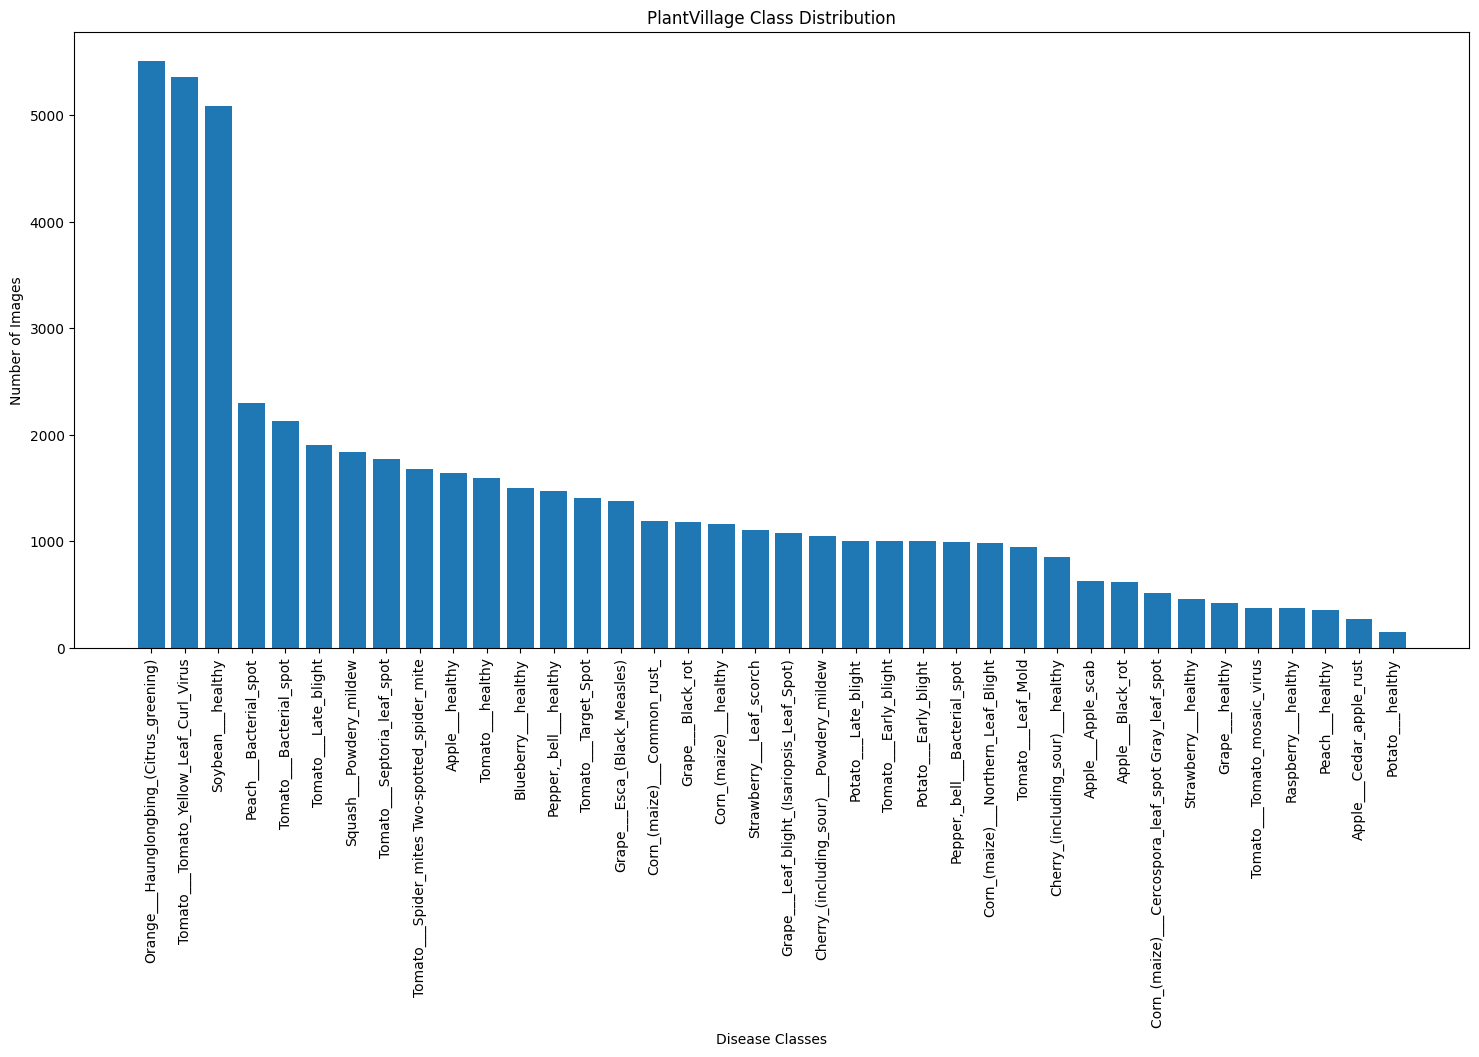

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 8))
plt.bar(class_counts_df["Class"], class_counts_df["Image_Count"])
plt.xticks(rotation=90)
plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")
plt.title("PlantVillage Class Distribution")
plt.show()

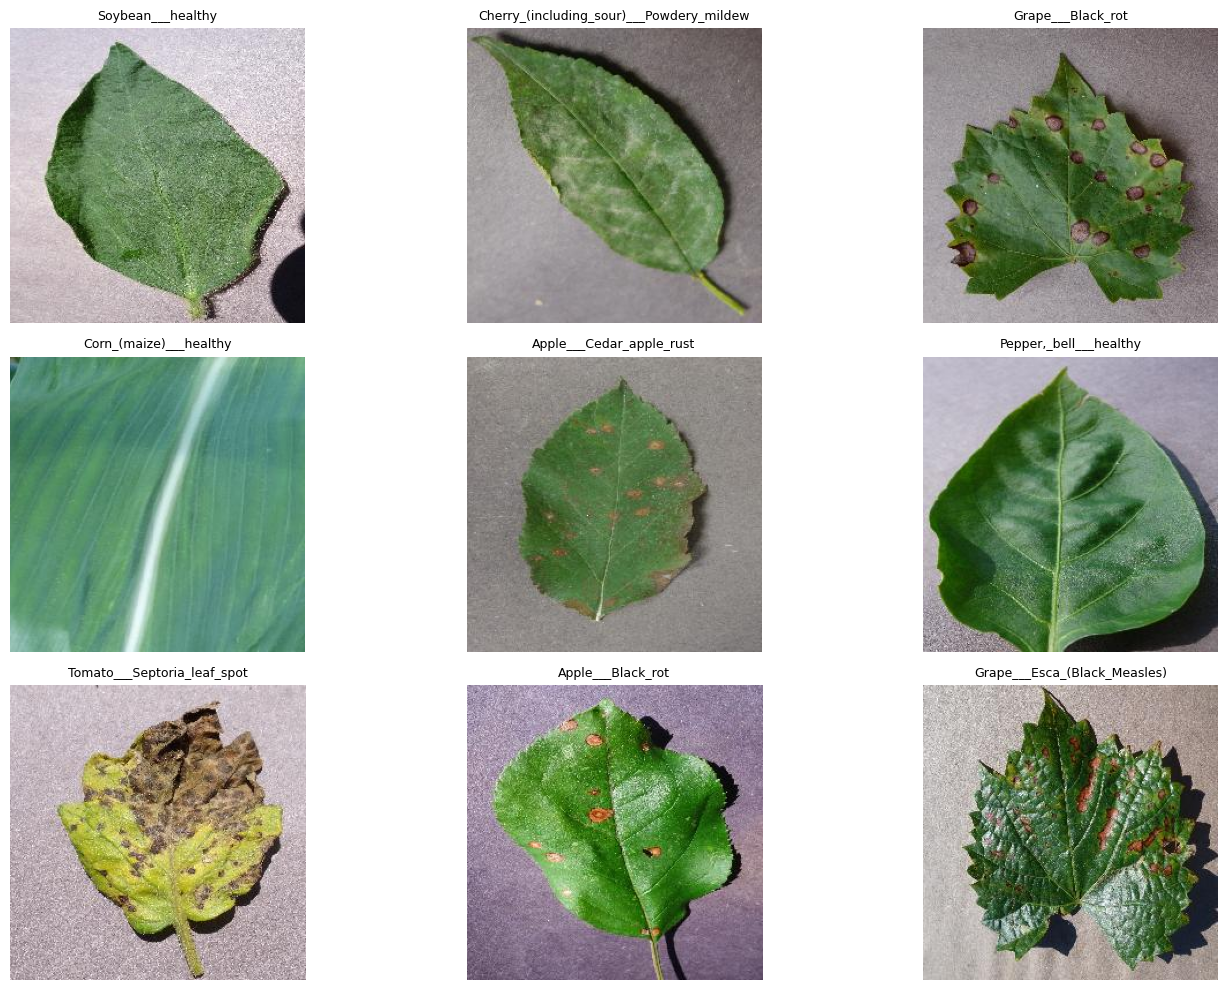

In [8]:
from PIL import Image
import random
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

sample_classes = random.sample(classes, 9)

for i, class_name in enumerate(sample_classes):
    class_path = os.path.join(base_dir, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
image_sizes = []

for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path)[:20]:
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path)
            image_sizes.append(img.size)

image_sizes_df = pd.DataFrame(image_sizes, columns=["Width", "Height"])

image_sizes_df.head()

,Width,Height
0,256,256
1,256,256
2,256,256
3,256,256
4,256,256


In [10]:
image_sizes = []

for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path)
                image_sizes.append(img.size)   
            except:
                print("Error reading image:", img_path)

image_sizes_df = pd.DataFrame(image_sizes, columns=["Width", "Height"])


print("Number of unique image sizes:", image_sizes_df.drop_duplicates().shape[0])


unique_sizes = image_sizes_df.value_counts().reset_index(name="Count")

unique_sizes

Number of unique image sizes: 1


,Width,Height,Count
0,256,256,54305


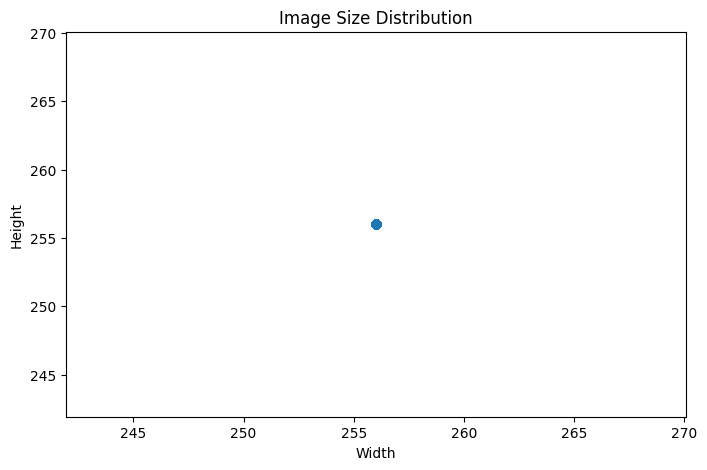

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(image_sizes_df["Width"], image_sizes_df["Height"])
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution")
plt.show()

In [12]:
img_path = os.path.join(base_dir, classes[0], os.listdir(os.path.join(base_dir, classes[0]))[0])

img = Image.open(img_path)

print("Image mode:", img.mode)
print("Image size:", img.size)

Image mode: RGB
Image size: (256, 256)


In [13]:
from PIL import Image

corrupted_images = []

for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path)
                img.verify()
            except:
                corrupted_images.append(img_path)

print("Corrupted images:", len(corrupted_images))

Corrupted images: 0


# Data Preprocessing

In [14]:
train_data = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_data = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int"
)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.


I0000 00:00:1779816801.474173     209 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779816801.480140     209 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [15]:
class_names = train_data.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Class names:")
print(class_names)

class_mapping_df = pd.DataFrame({
    "Class_Index": range(len(class_names)),
    "Class_Name": class_names
})

class_mapping_df

Number of classes: 38
Class names:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotte

,Class_Index,Class_Name
0,0,Apple___Apple_scab
1,1,Apple___Black_rot
2,2,Apple___Cedar_apple_rust
3,3,Apple___healthy
4,4,Blueberry___healthy
5,5,Cherry_(including_sour)___Powdery_mildew
6,6,Cherry_(including_sour)___healthy
7,7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...
8,8,Corn_(maize)___Common_rust_
9,9,Corn_(maize)___Northern_Leaf_Blight


In [16]:
for images, labels in train_data.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image pixel range:", images.numpy().min(), images.numpy().max())
    print("Labels:", labels.numpy()[:10])

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Image pixel range: 0.0 255.0
Labels: [24 15 15  6 15 24 21  1 24  7]


In [17]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.prefetch(buffer_size=AUTOTUNE)

In [19]:
from sklearn.utils.class_weight import compute_class_weight

class_counts = []

for class_name in class_names:
    class_path = os.path.join(base_dir, class_name)
    class_counts.append(len(os.listdir(class_path)))

y_labels = []

for index, count in enumerate(class_counts):
    y_labels.extend([index] * count)

y_labels = np.array(y_labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_labels
)

class_weights_dict = dict(enumerate(class_weights))

print(class_weights_dict)

{0: np.float64(2.268379281537176), 1: np.float64(2.3012543435884396), 2: np.float64(5.196650717703349), 3: np.float64(0.8687410014397696), 4: np.float64(0.9514506973158595), 5: np.float64(1.358440064038423), 6: np.float64(1.6733945519536546), 7: np.float64(2.7857289422386375), 8: np.float64(1.1988917343694807), 9: np.float64(1.4508415709324072), 10: np.float64(1.229844188785216), 11: np.float64(1.2110838537020518), 12: np.float64(1.0333181108954599), 13: np.float64(1.328140285658384), 14: np.float64(3.378437227821326), 15: np.float64(0.25950226028117324), 16: np.float64(0.6221501729945238), 17: np.float64(3.9696637426900585), 18: np.float64(1.433379084622288), 19: np.float64(0.9669005056619899), 20: np.float64(1.4290789473684211), 21: np.float64(1.4290789473684211), 22: np.float64(9.401835180055402), 23: np.float64(3.851964817704639), 24: np.float64(0.28076207217454247), 25: np.float64(0.7787896170945073), 26: np.float64(1.2886194295477196), 27: np.float64(3.1339450600184673), 28: np.f

In [20]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# Model Selection & Training

In [21]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

base_model = EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)


base_model.trainable = False


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [22]:
from tensorflow.keras import  models

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,103,369 (15.65 MB)

 Trainable params: 51,238 (200.15 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [24]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        filepath="/kaggle/working/best_disease_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [25]:
EPOCHS = 10

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights_dict
)

Epoch 1/10


E0000 00:00:1779816959.287691     209 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1779816981.251295     271 cuda_dnn.cc:529] Loaded cuDNN version 91002


2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7552 - loss: 0.9735
Epoch 1: val_accuracy improved from -inf to 0.92947, saving model to /kaggle/working/best_disease_model.keras
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 170s 50ms/step - accuracy: 0.7552 - loss: 0.9732 - val_accuracy: 0.9295 - val_loss: 0.2247 - learning_rate: 0.0010
Epoch 2/10
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9097 - loss: 0.2984
Epoch 2: val_accuracy improved from 0.92947 to 0.94568, saving model to /kaggle/working/best_disease_model.keras
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 147s 49ms/step - accuracy: 0.9097 - loss: 0.2984 - val_accuracy: 0.9457 - val_loss: 0.1685 - learning_rate: 0.0010
Epoch 3/10
2715/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9182 - loss: 0.2765
Epoch 3: val_accuracy improved from 0.94568 to 0.95323, saving model to /kaggle/working/best_disease_model.keras
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 144s 49ms/step - accuracy: 0.9182 - loss: 0.2765 - val_accuracy: 0.9532 - val_loss: 0

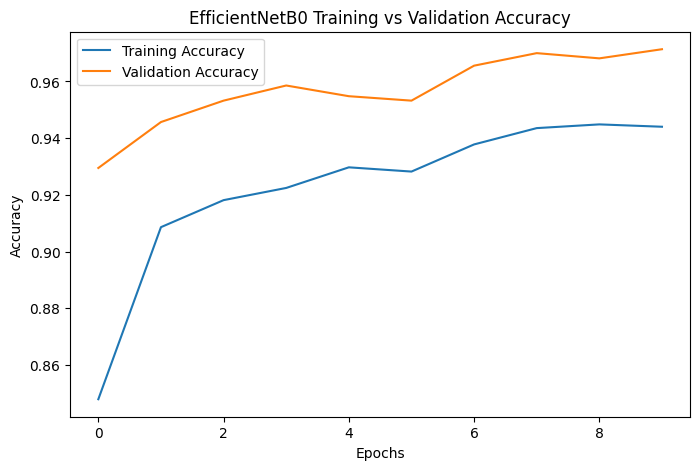

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 Training vs Validation Accuracy")
plt.legend()
plt.show()

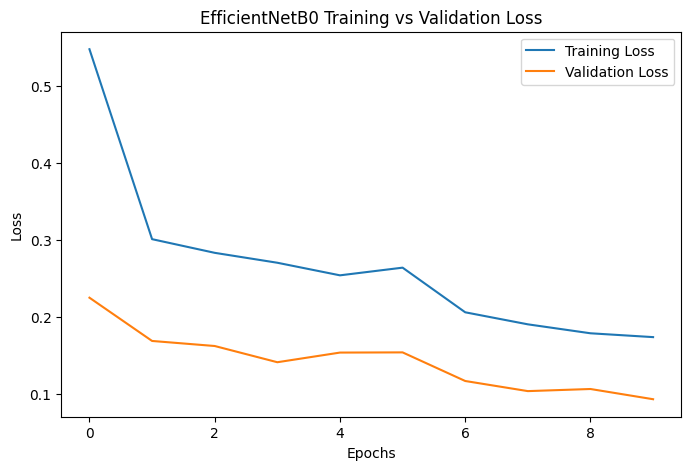

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("EfficientNetB0 Training vs Validation Loss")
plt.legend()
plt.show()

# Fine Tuning

In [28]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [29]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [30]:
FINE_TUNE_EPOCHS = 5

fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights_dict
)

Epoch 1/5


E0000 00:00:1779818508.026264     209 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8799 - loss: 0.4551
Epoch 1: val_accuracy improved from 0.97137 to 0.97450, saving model to /kaggle/working/best_disease_model.keras
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 190s 59ms/step - accuracy: 0.8799 - loss: 0.4550 - val_accuracy: 0.9745 - val_loss: 0.0914 - learning_rate: 1.0000e-04
Epoch 2/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9497 - loss: 0.1721
Epoch 2: val_accuracy improved from 0.97450 to 0.97947, saving model to /kaggle/working/best_disease_model.keras
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 173s 58ms/step - accuracy: 0.9497 - loss: 0.1721 - val_accuracy: 0.9795 - val_loss: 0.0765 - learning_rate: 1.0000e-04
Epoch 3/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9622 - loss: 0.1248
Epoch 3: val_accuracy improved from 0.97947 to 0.98407, saving model to /kaggle/working/best_disease_model.keras
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 171s 57ms/step - accuracy: 0.9622 - loss: 0.1248 - val_accuracy: 0.9841 - va

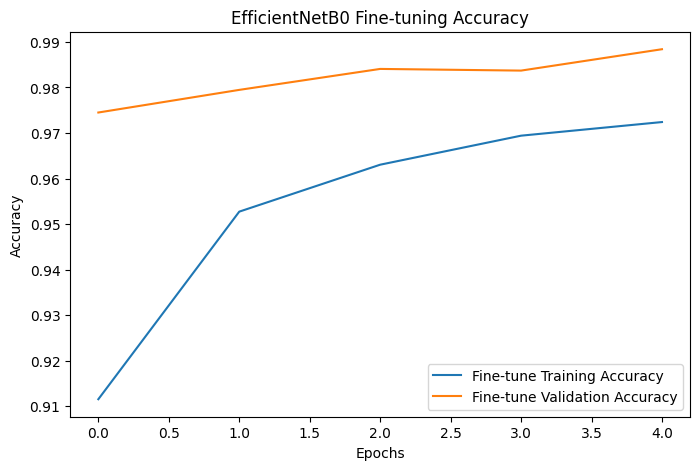

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(fine_tune_history.history["accuracy"], label="Fine-tune Training Accuracy")
plt.plot(fine_tune_history.history["val_accuracy"], label="Fine-tune Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 Fine-tuning Accuracy")
plt.legend()
plt.show()

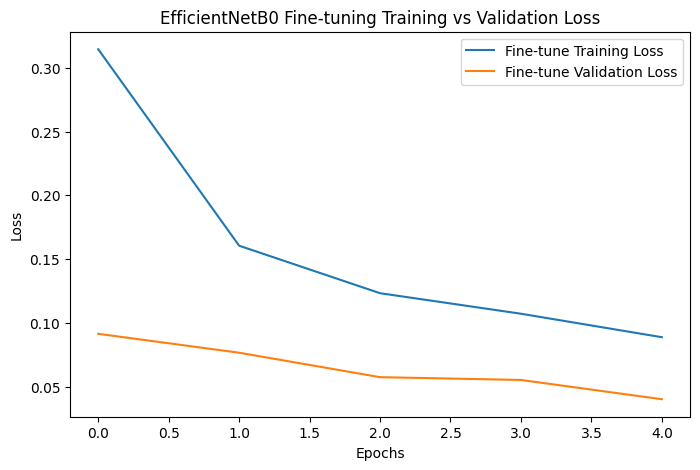

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(fine_tune_history.history["loss"], label="Fine-tune Training Loss")
plt.plot(fine_tune_history.history["val_loss"], label="Fine-tune Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("EfficientNetB0 Fine-tuning Training vs Validation Loss")
plt.legend()
plt.show()

# Model Evaluation

In [33]:
test_loss, test_accuracy = model.evaluate(val_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

679/679 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.9868 - loss: 0.0485
Test Loss: 0.04002033546566963
Test Accuracy: 0.9883988499641418


In [35]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_data:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.96      0.98       126
                                 Apple___Black_rot       0.99      1.00      1.00       132
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       0.98      1.00      0.99       329
                               Blueberry___healthy       1.00      1.00      1.00       295
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       232
                 Cherry_(including_sour)___healthy       1.00      0.98      0.99       167
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.90      0.93       108
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       219
               Corn_(maize)___Northern_Leaf_Blight       0.95      0.98      0.

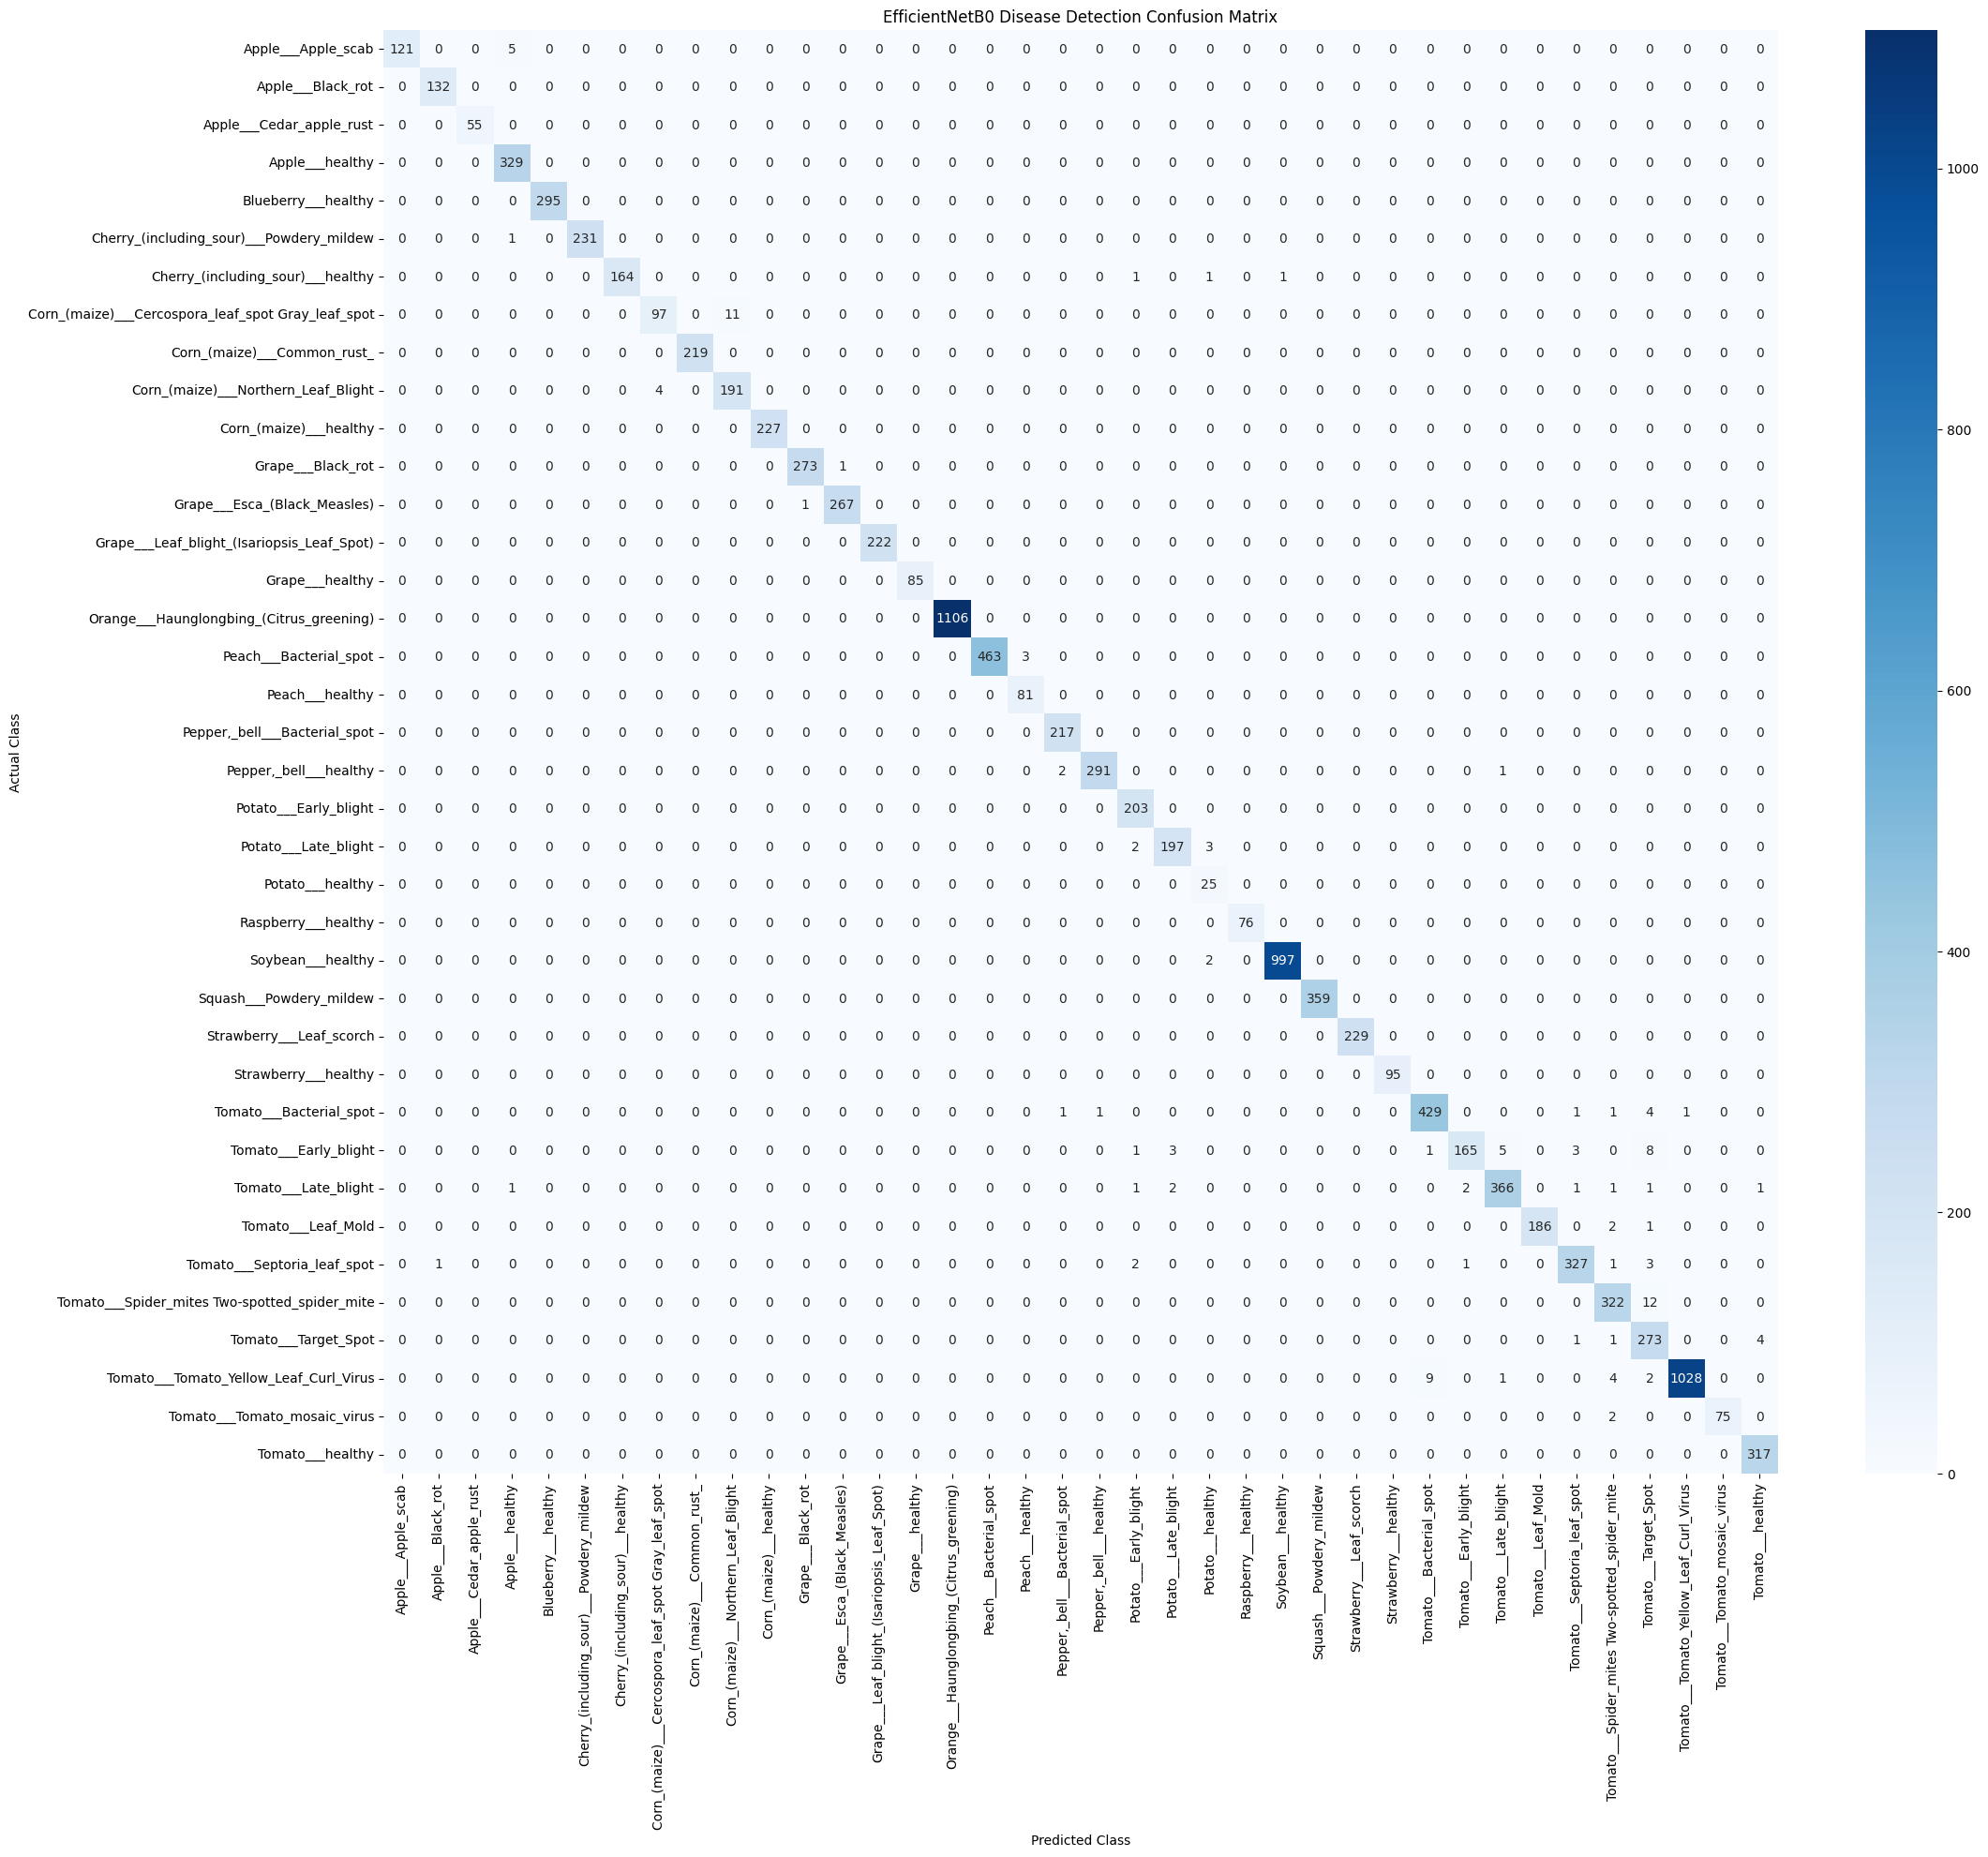

In [39]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(24, 20))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("EfficientNetB0 Disease Detection Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

Actual Class: Peach___Bacterial_spot
Image Path: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color/Peach___Bacterial_spot/59098ed3-2a86-443a-af81-44e6ec28112a___Rut._Bact.S 0763.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step
Predicted Class: Peach___Bacterial_spot
Confidence: 92.6 %


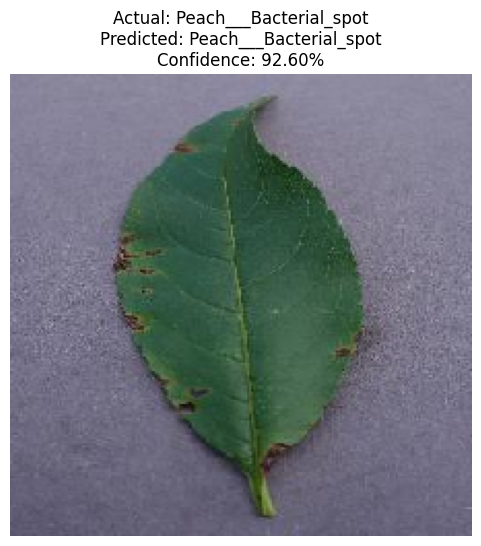

In [40]:
from tensorflow.keras.preprocessing import image


actual_class = random.choice(class_names)


class_path = os.path.join(base_dir, actual_class)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

print("Actual Class:", actual_class)
print("Image Path:", img_path)


img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))


img_array = image.img_to_array(img)


img_array = np.expand_dims(img_array, axis=0)


prediction = model.predict(img_array)


predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]


confidence = np.max(prediction[0]) * 100

print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")


plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.axis("off")
plt.show()

In [41]:
import json


model.save("/kaggle/working/disease_model.keras")


with open("/kaggle/working/disease_class_names.json", "w") as f:
    json.dump(class_names, f)

print("Disease model and class names saved successfully!")

Disease model and class names saved successfully!
